# The 29-Year Streak Ends: A Data-Driven Autopsy of VfL Wolfsburg's Relegation

At the end of the 2025/26 Bundesliga season, VfL Wolfsburg was relegated, ending an incredible 29-year streak in Germany's top flight. To the casual fan, a relegation often feels like a sudden stroke of bad luck or a single disastrous season. However, as a data analyst, I wanted to look beneath the surface. Did the data predict this?

Using match data from the last five seasons (2021–2026), this project will explore Wolfsburg's underlying performance metrics to uncover the true story of their exit.

**The Task**: Determine if VfL Wolfsburg's relegation in the 25/26 season was a sudden anomaly or the result of a long-term, systemic decline in finishing efficiency.

**Key Questions:**

1. How did Wolfsburg's actual Goals compare to their Expected Goals (xG) over the last 5 years?

2. Compared to other consistently top-flight clubs, where did Wolfsburg rank in attacking efficiency?


**Data Source**: All match data, including the Expected Goals (xG) metrics, were sourced from Understat (https://understat.com/). The dataset aggregates matchday statistics across five Bundesliga seasons (2021/22 – 2025/26).

# Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import pathlib
# This line makes charts appear directly inside the notebook
%matplotlib inline

print('Libraries loaded successfully.')

Libraries loaded successfully.


# Step 2: Load Data

In [2]:
from pathlib import Path
FOLDER = Path('/kaggle/input/datasets/antwanmakramallah/bundesliga-dataset-2021-2026')

# Load each season into a clearly named variable
season_2122 = pd.read_csv(FOLDER / 'Bundesliga 21-22.csv', sep=';')
season_2223 = pd.read_csv(FOLDER / 'Bundesliga 22-23.csv', sep=';')
season_2324 = pd.read_csv(FOLDER / 'Bundesliga 23-24.csv', sep=';')
season_2425 = pd.read_csv(FOLDER / 'Bundesliga 24-25.csv', sep=';')
season_2526 = pd.read_csv(FOLDER / 'Bundesliga 25-26.csv', sep=';')

print('All 5 seasons loaded successfully.')

All 5 seasons loaded successfully.


# Step 3: Inspect Data

In [3]:
#Shape of the data
print('Shape of the 2023/24 dataset', season_2324.shape)

# Show the first 5 rows
season_2324.head()

Shape of the 2023/24 dataset (18, 12)


,number,team,matches,wins,draws,loses,goals,ga,points,xG,xGA,xPTS
0,1,Bayer Leverkusen,34,28,6,0,89,24,90,82.01,32.43,76.17
1,2,VfB Stuttgart,34,23,4,7,78,39,73,78.99,42.50,69.50
2,3,Bayern Munich,34,23,3,8,94,45,72,94.40,35.22,76.98
3,4,RasenBallsport Leipzig,34,19,8,7,77,39,65,72.63,43.25,64.21
4,5,Borussia Dortmund,34,18,9,7,68,43,63,71.16,55.27,56.88


In [4]:
# Check for missing values
print('Missing values in 2023/24:')
print(season_2324.isnull().sum())


Missing values in 2023/24:
number     0
team       0
matches    0
wins       0
draws      0
loses      0
goals      0
ga         0
points     0
xG         0
xGA        0
xPTS       0
dtype: int64


# Step 4: Clean Data

Data from different seasons can often be messy. Following the principles of data integrity, I am building an ETL (Extract, Transform, Load) function to standardize column names, fix data types, and engineer the core metric we need: Finishing Differential (Goals - xG).

If a team has a negative differential, they are chronically missing high-quality chances.

In [5]:
def clean_season(df, season_label):
    """
    Clean one season dataframe.
    Parameters:
        df:                raw dataframe loaded from csv
        season_label:      a string like '23/24' to label this season
    Returns:
        a cleaned dataframe with standarized columns and new metrics
    """

    #make a copy of the df
    df = df.copy()

    #remove spaces from columns names
    df.columns = df.columns.str.strip()

    ##remove spaces around teams names 
    df['team']= df['team'].str.strip()

    #convert goals and xG to numbers
    df['goals']= pd.to_numeric(df['goals'], errors='coerce')
    df['xG']= pd.to_numeric(df['xG'], errors='coerce')

    #add a label so we know which season this row came from
    df['season']= season_label

    #calculate the difference between scored goal and xG
    df['difference'] = df['goals'] - df['xG']

    return df

#apply function to all 5 seasons
season_2122 = clean_season(season_2122, '21/22')
season_2223 = clean_season(season_2223, '22/23')
season_2324 = clean_season(season_2324, '23/24')
season_2425 = clean_season(season_2425, '24/25')
season_2526 = clean_season(season_2526, '25/26')

print('All seasons cleaned.')
print()
print('Example: 2023/24 after cleaning:')
season_2324[['number','team','goals','xG','difference','season']].head()

All seasons cleaned.

Example: 2023/24 after cleaning:


,number,team,goals,xG,difference,season
0,1,Bayer Leverkusen,89,82.01,6.99,23/24
1,2,VfB Stuttgart,78,78.99,-0.99,23/24
2,3,Bayern Munich,94,94.40,-0.40,23/24
3,4,RasenBallsport Leipzig,77,72.63,4.37,23/24
4,5,Borussia Dortmund,68,71.16,-3.16,23/24


In [6]:
# Stack all 5 seasons into one big dataframe
all_seasons = pd.concat(
    [season_2122, season_2223, season_2324, season_2425, season_2526],
    ignore_index=True    #reset the row index number
)

print('combined dataframe shape:', all_seasons.shape)
print('Seasons present;', all_seasons['season'].unique())

combined dataframe shape: (90, 14)
Seasons present; ['21/22' '22/23' '23/24' '24/25' '25/26']



# Step 5: Visualization Goals vs. xG Scatterplot (All 5 seasons)

Now that our data is clean, we can start finding the story.
First, i want to check the top 3 overperforming and underperforming teams using scatterplot



In [7]:
# Define colors and style
COLOR_OVER  = '#69db7c'   # green  — scored more than xG predicted
COLOR_UNDER = '#ff6b6b'   # red    — scored less than xG predicted
COLOR_BG    = '#0d1117'   # dark background for the whole figure
COLOR_PANEL = '#161b22'   # slightly lighter background for each chart area
COLOR_TEXT  = '#e6edf3'   # light color for titles and labels
COLOR_MUTED = '#8b949e'   # grey for secondary labels
COLOR_GRID  = '#30363d'   # subtle grid lines

print('Color constants defined.')

Color constants defined.


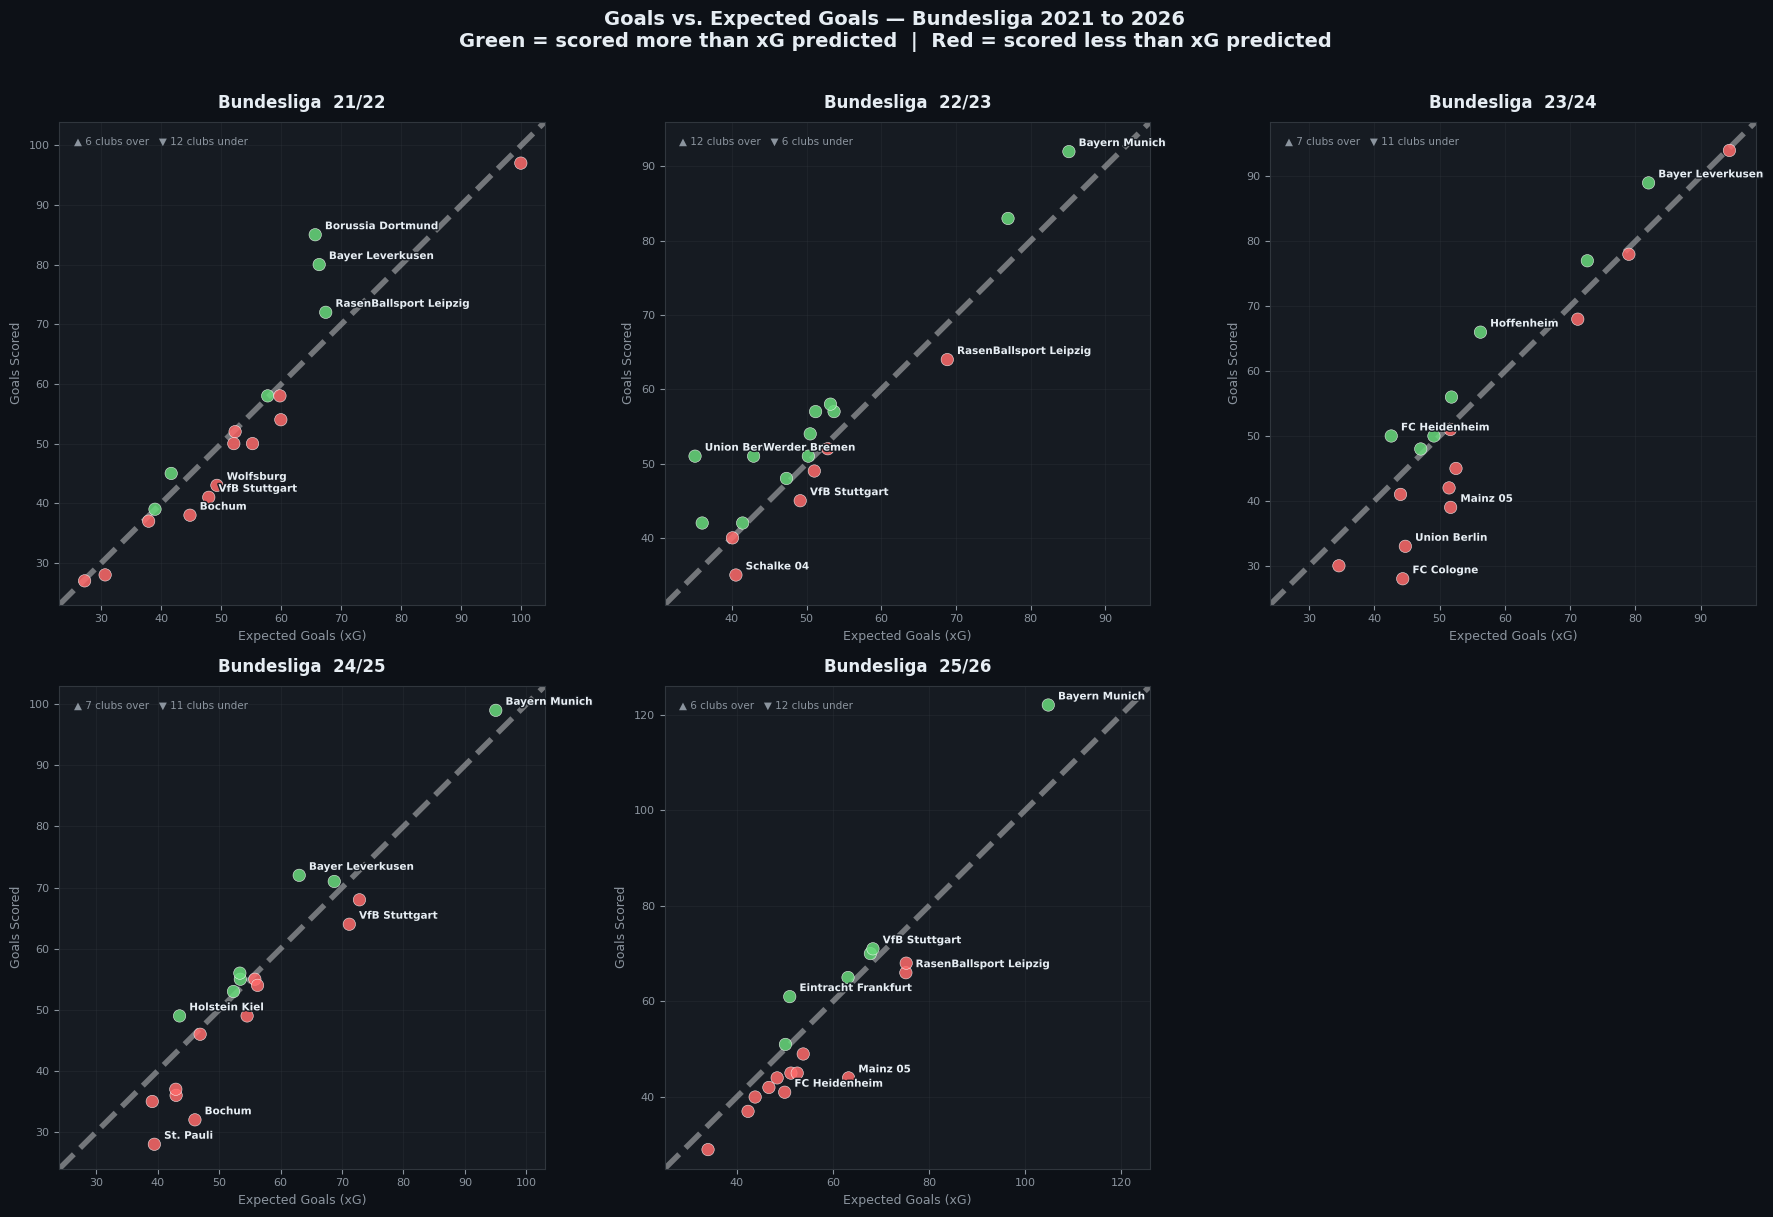

Chart saved.


In [8]:
# Put all seasons in lists so we can loop through them easily
all_season_dfs = [season_2122, season_2223, season_2324, season_2425, season_2526]
all_season_names = ['21/22', '22/23', '23/24', '24/25', '25/26']

#create figures
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18,12))
fig.patch.set_facecolor(COLOR_BG)

#turn axes into 1D list
axes_list = axes.flatten()

#loop through 5 seasons
for i in range(5):
    df = all_season_dfs[i]
    season_name = all_season_names[i]
    ax = axes_list[i]

    ax.set_facecolor(COLOR_PANEL)

    #Step A:Choose color for overperforming (green) and underperforming (red) teams
    dot_colors =[]
    for value in df['difference']:
        if value >0:
            dot_colors.append(COLOR_OVER)
        else:
            dot_colors.append(COLOR_UNDER)

    #step B:Draw scatterplot
    ax.scatter(
        df['xG'],                    # x-axis: expected goals
        df['goals'],                 # y-axis: actual goals scored
        color=dot_colors,
        s=80,                        # dot size in points squared
        alpha=.85,                   # slight transparency
        edgecolors='white',
        linewidth=0.4,
        zorder=3                     # draw dots above grid lines
    )

    #Step C: draw the reference diagonal line
    min_val= min(df['xG'].min(), df['goals'].min()) -4
    max_val= max(df['xG'].max(), df['goals'].max()) +4

    ax.plot(
        [min_val, max_val],                   # x-axis start and end points
        [min_val, max_val],                   # y-axis start and end points (same = 45-degree line)
        color='white',
        linestyle='--',
        linewidth=4,
        alpha=0.4
    )
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)            

    #step D: Add tex labels for top 3 overperformers and underperformers
    top_3_over = df.nlargest(3, 'difference')      # 3 highest positive values
    top_3_under = df.nsmallest(3,'difference')     # 3 lowest (most negative) values
    clubs_to_label = pd.concat([top_3_over, top_3_under])

    for _, row in clubs_to_label.iterrows():
        ax.annotate(
            text=row['team'],
            xy=(row['xG'], row['goals']),     # where the dot is
            xytext=(7, 4),                    # offset the text 7 px right, 4 px up
            textcoords='offset points',
            fontsize=7.5,
            color=COLOR_TEXT,
            fontweight='bold',
            # withStroke adds a dark outline behind the text for readability
            path_effects=[
                pe.withStroke(linewidth=2, foreground=COLOR_PANEL)
            ]
        )

        # Step E: Style the subplot
    ax.set_title(f'Bundesliga  {season_name}',
                 color=COLOR_TEXT, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Expected Goals (xG)', color=COLOR_MUTED, fontsize=9)
    ax.set_ylabel('Goals Scored',        color=COLOR_MUTED, fontsize=9)
    ax.tick_params(colors=COLOR_MUTED, labelsize=8)
    ax.grid(True, color=COLOR_GRID, linewidth=0.4, alpha=0.6)
    for spine in ax.spines.values():
        spine.set_color(COLOR_GRID)

    # Step F: Small count in the top-left corner
    n_over  = (df['difference'] > 0).sum()
    n_under = (df['difference'] < 0).sum()
    ax.text(
        0.03, 0.97,
        f'▲ {n_over} clubs over   ▼ {n_under} clubs under',
        transform=ax.transAxes,  # use 0-to-1 coordinates relative to the axes
        fontsize=7.5, color=COLOR_MUTED, va='top'
    )
        
# Hide the unused 6th panel
axes_list[5].set_visible(False)

# Main title for the whole figure
fig.suptitle(
'Goals vs. Expected Goals — Bundesliga 2021 to 2026\n'
'Green = scored more than xG predicted  |  Red = scored less than xG predicted',
color=COLOR_TEXT, fontsize=14, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig(r'C:\Users\antwa\OneDrive\Desktop\Game Analysis\Project 1 — Bundesliga Season Dashboard\bundesliga-eda\outputs\figures\01_goals_vs_xg_all_seasons.png',
            dpi=150, bbox_inches='tight', facecolor=COLOR_BG)
plt.show()
print('Chart saved.')
    

# Check the performance of Wolfsburg over 5 seasons

Here, I want to isolate VfL Wolfsburg's trajectory. To understand their finishing efficiency, I will plot their Actual Goals against their Expected Goals (xG) over the 5-year window. The gap between these two lines will show us exactly when they were overperforming (scoring more than expected) and when they were underperforming (missing quality chances).

In [9]:
team_name = 'Wolfsburg'

team_performance = all_seasons[all_seasons['team'] == team_name].copy()

print(team_performance[['team', 'season', 'goals', 'xG', 'difference']])

         team season  goals     xG  difference
11  Wolfsburg  21/22     43  49.27       -6.27
25  Wolfsburg  22/23     57  51.21        5.79
47  Wolfsburg  23/24     41  44.00       -3.00
64  Wolfsburg  24/25     56  53.38        2.62
87  Wolfsburg  25/26     45  52.58       -7.58


In [10]:
# Define the correct order
season_order = ['21/22', '22/23', '23/24', '24/25', '25/26']

# Reorder the rows to match that order
team_performance = team_performance.set_index('season').reindex(season_order).reset_index()

print(team_performance[['season', 'goals', 'xG', 'difference']])

  season  goals     xG  difference
0  21/22     43  49.27       -6.27
1  22/23     57  51.21        5.79
2  23/24     41  44.00       -3.00
3  24/25     56  53.38        2.62
4  25/26     45  52.58       -7.58


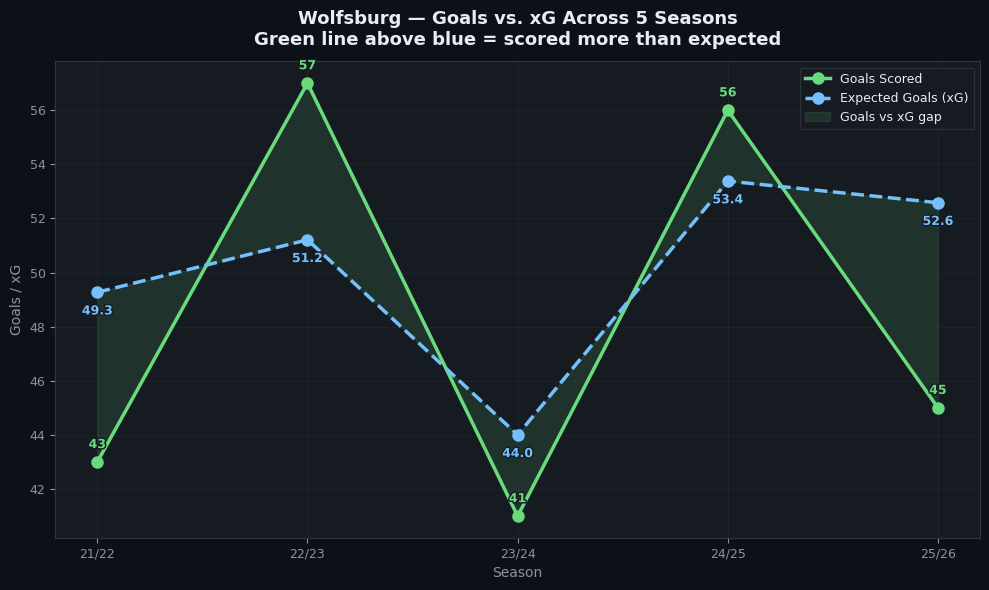

Chart saved.


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(COLOR_BG)
ax.set_facecolor(COLOR_PANEL)

# Draw the Goals line
ax.plot(
    team_performance['season'],    # x-axis: the 5 seasons
    team_performance['goals'],     # y-axis: actual goals scored
    marker='o',                   # show a dot at each season
    linewidth=2.5,
    markersize=8,
    color='#69db7c',              # green
    label='Goals Scored'
)

# Draw the xG line
ax.plot(
    team_performance['season'],
    team_performance['xG'],
    marker='o',
    linewidth=2.5,
    markersize=8,
    color='#74c0fc',              # blue
    linestyle='--',               # dashed to visually separate from Goals line
    label='Expected Goals (xG)'
)

# Add value labels above each dot
# Goals labels
for _, row in team_performance.iterrows():
    ax.annotate(
        f"{int(row['goals'])}",           # the number to display
        xy=(row['season'], row['goals']),
        xytext=(0, 10),                   # 10 pixels above the dot
        textcoords='offset points',
        fontsize=9,
        color='#69db7c',
        fontweight='bold',
        ha='center',
        path_effects=[pe.withStroke(linewidth=2, foreground=COLOR_PANEL)]
    )

# xG labels
for _, row in team_performance.iterrows():
    ax.annotate(
        f"{row['xG']:.1f}",               # one decimal place
        xy=(row['season'], row['xG']),
        xytext=(0, -16),                  # 16 pixels below the dot
        textcoords='offset points',
        fontsize=9,
        color='#74c0fc',
        fontweight='bold',
        ha='center',
        path_effects=[pe.withStroke(linewidth=2, foreground=COLOR_PANEL)]
    )

# hade the gap between the two lines
# This visually shows when Leverkusen was over or under their xG
ax.fill_between(
    team_performance['season'],
    team_performance['goals'],
    team_performance['xG'],
    alpha=0.12,
    color='#69db7c',
    label='Goals vs xG gap'
)

#Styling
ax.set_title(
    f'{team_name} — Goals vs. xG Across 5 Seasons\n'
    f'Green line above blue = scored more than expected',
    color=COLOR_TEXT, fontsize=13, fontweight='bold', pad=12
)
ax.set_xlabel('Season',       color=COLOR_MUTED, fontsize=10)
ax.set_ylabel('Goals / xG',   color=COLOR_MUTED, fontsize=10)
ax.tick_params(colors=COLOR_MUTED, labelsize=9)
ax.grid(True, color=COLOR_GRID, linewidth=0.4, alpha=0.6)
ax.legend(facecolor=COLOR_PANEL, edgecolor=COLOR_GRID,
          labelcolor=COLOR_TEXT, fontsize=9)
for spine in ax.spines.values():
    spine.set_color(COLOR_GRID)

plt.tight_layout()
plt.show()
print('Chart saved.')

# Summary Table: Structural Profiles Across 5 Seasons

Observation 1: Wolfsburg were in five seasons more underperforming than overperforming by looking to the difference between the green line and blue line. Looking at the visualization above, the blue line (xG) frequently sits higher than the green line (Actual Goals). Aside from a slight overperformance in 22/23, Wolfsburg was chronically failing to convert their expected chances. By the time they hit the 24/25 and 25/26 seasons, the gap had widened significantly. They were mathematically starving themselves of the goals needed to secure survival points.

But how does this systemic underperformance compare to the rest of the league? To find out, I will filter the dataset to only include the 12 core teams that survived all 5 seasons. Where does Wolfsburg rank among their peers?

In [12]:
# First, define consistent_clubs - clubs that appear in all seasons
# Assuming 'all_seasons' DataFrame exists with 'team' column
consistent_clubs = all_seasons['team'].value_counts()
consistent_clubs = consistent_clubs[consistent_clubs == 5].index.tolist()  # Clubs appearing in all 5 seasons

# Build the summary table row by row
summary_rows = []

for club in consistent_clubs:
    # Get all rows for this club across all 5 seasons
    club_data = all_seasons[all_seasons['team'] == club]

    # Count seasons where the club was above / below 0
    seasons_over  = (club_data['difference'] > 0).sum()
    seasons_under = (club_data['difference'] < 0).sum()

    # Average Goals minus xG across all 5 seasons
    avg_diff = club_data['difference'].mean()

    # Classify based on the average
    if avg_diff > 3:
        profile = 'Structural Overperformer'
    elif avg_diff > 0:
        profile = 'Slight Overperformer'
    elif avg_diff > -3:
        profile = 'Slight Underperformer'
    else:
        profile = 'Structural Underperformer'

    # Add this club as a row in our results list
    summary_rows.append({
        'Club':           club,
        'Seasons Over':   seasons_over,
        'Seasons Under':  seasons_under,
        'Avg Goals − xG': round(avg_diff, 2),
        'Profile':        profile
    })

# Convert the list of rows into a dataframe
summary_df = pd.DataFrame(summary_rows)

# Sort by Avg Goals minus xG: best finishers at the top
summary_df = summary_df.sort_values('Avg Goals − xG', ascending=False)
summary_df = summary_df.reset_index(drop=True)

# Display with a color gradient
print('5-Season Finishing Profile — Bundesliga 2021–2026')
summary_df.style \
    .background_gradient(subset=['Avg Goals − xG'], cmap='RdYlGn', vmin=-8, vmax=8) \
    .format({'Avg Goals − xG': '{:+.2f}'}) \
    .set_caption('Positive = consistent outperformer | Negative = consistent underperformer')

5-Season Finishing Profile — Bundesliga 2021–2026


,Club,Seasons Over,Seasons Under,Avg Goals − xG,Profile
0,Borussia Dortmund,4,1,+5.34,Structural Overperformer
1,Bayer Leverkusen,4,1,+5.14,Structural Overperformer
2,Bayern Munich,3,2,+4.95,Structural Overperformer
3,Eintracht Frankfurt,3,2,+2.53,Slight Overperformer
4,Hoffenheim,3,2,+1.92,Slight Overperformer
5,Augsburg,3,2,-0.70,Slight Underperformer
6,RasenBallsport Leipzig,3,2,-0.88,Slight Underperformer
7,Borussia M.Gladbach,2,3,-1.14,Slight Underperformer
8,Wolfsburg,2,3,-1.69,Slight Underperformer
9,Freiburg,3,2,-2.23,Slight Underperformer


# Conclusion

VfL Wolfsburg’s relegation in the 2025/26 season was not a sudden stroke of bad luck, it was the mathematical result of a 5-year systemic decay. The widening gap between Expected Goals (blue line) and Actual Goals (green line) reveals a chronic inability to convert high-probability chances. Ranking 9th out of the 12 core Bundesliga clubs in finishing efficiency proved they were structurally failing long before their exit.

**Thank you for reading my analysis! Feedback and discussions are highly welcome in the comments.**